In [34]:
import pandas as pd
consumer = pd.read_parquet("parquet/Consumer_Staples.parquet")
finance = pd.read_parquet("parquet/Financials.parquet")
it = pd.read_parquet("parquet/Information_Technology.parquet")

In [35]:
dataframe_dict = {'consumer' : consumer, 'finance': finance, 'it' : it}

In [75]:
tickers_per_sector = {}

for sector, df in dataframe_dict.items():
    tickers = df.index.get_level_values("ticker").unique().tolist()
    tickers_per_sector[sector] = tickers

tickers_per_sector

{'consumer': ['COST', 'PG', 'WMT'],
 'finance': ['CME', 'GS', 'WFC'],
 'it': ['AAPL', 'IBM', 'MSFT']}

In [36]:
for sector, df in dataframe_dict.items():
    print("Processing sector:", sector)
    df = df.sort_index()
    
    filtered_list = []
    for ticker, subdf in df.groupby(level="ticker"):
        subdf = subdf.droplevel("ticker")
        
        # Keep only market hours
        subdf = subdf.between_time("09:30", "16:00")
        
        # Keep only rows between 2020-09-12 and 2025-08-04
        subdf = subdf.loc["2020-09-15":"2025-08-04"]
        
        # Add ticker back as column
        subdf["ticker"] = ticker
        filtered_list.append(subdf)
    
    # Rebuild MultiIndex
    df = pd.concat(filtered_list)
    df = df.set_index(["ticker", df.index])
    df.index.names = ["ticker", "timestamp"]
    
    dataframe_dict[sector] = df

Processing sector: consumer
Processing sector: finance
Processing sector: it


In [37]:
for sector, df in dataframe_dict.items():
    print(f"\nSector: {sector}")

    # Drop ticker column if present
    data_cols = df.columns.drop('ticker', errors='ignore')

    # Create a boolean DataFrame: True if row is all NaN across tickers
    # First, unstack tickers so rows = timestamps, columns = tickers
    df_unstacked = df[data_cols].unstack(level='ticker')  # columns become MultiIndex (col, ticker)

    # For each timestamp, check if all tickers are NaN for all columns
    all_nan_mask = df_unstacked.isna().all(axis=1)

    # Extract the timestamps where this is True
    missing_dates = all_nan_mask[all_nan_mask].index

    # Only get unique dates
    missing_unique_dates = pd.to_datetime(missing_dates).normalize().unique()

    if len(missing_unique_dates) > 0:
        print("Dates where all tickers have NaN:")
        for d in missing_unique_dates:
            print(d.date())
    else:
        print("No dates with all-NaN across tickers.")


Sector: consumer
No dates with all-NaN across tickers.

Sector: finance
No dates with all-NaN across tickers.

Sector: it
No dates with all-NaN across tickers.


In [38]:
for sector, df in dataframe_dict.items():
    time_diffs = df.groupby(level='ticker').apply(lambda g: g.index.get_level_values('timestamp').to_series()
                                                  .pipe(lambda x: x.diff().where(x.dt.date == x.shift().dt.date))).dropna()
    time_diffs = time_diffs[time_diffs != pd.Timedelta('1min')]
    ticker_gaps = time_diffs.groupby(level='ticker').median()
    print(f'{sector} has a median value range of {ticker_gaps.median()}')

consumer has a median value range of 0 days 00:05:00
finance has a median value range of 0 days 00:04:00
it has a median value range of 0 days 00:03:00


From this, I'm making the time series into 5 min intervals instead, given that the median of the non 1-minutes ones has a median of 5 minutes. The data here will be forward-filled.

In [39]:
cols = ['open', 'high', 'low', 'close', 'volume']

for sector, df in dataframe_dict.items():
    print("Resampling sector:", sector)
    df = df.copy().sort_index()

    # Trading days
    all_days = df.index.get_level_values("timestamp").normalize().unique()

    # Intraday 5-min timestamps
    intraday_times = pd.date_range(
        "09:30", "16:00", freq="5min", inclusive="both"
    ).time

    # Master timeline
    full_ts = pd.DatetimeIndex([
        pd.Timestamp(day).replace(hour=t.hour, minute=t.minute)
        for day in all_days
        for t in intraday_times
    ])

    result_list = []

    for ticker, sub in df.groupby(level="ticker"):
        sub = sub.droplevel("ticker")
        sub.index = pd.to_datetime(sub.index)

        # Resample FIRST
        df_5min = sub.resample("5min", label="right", closed="right").agg({
            "open": "first",
            "high": "max",
            "low": "min",
            "close": "last",
            "volume": "sum"
        })

        # THEN reindex to grid
        df_5min = df_5min.reindex(full_ts).ffill()

        df_5min["ticker"] = ticker
        df_5min = df_5min.set_index("ticker", append=True)
        df_5min.index.names = ["timestamp", "ticker"]
        df_5min = df_5min.reorder_levels(["ticker", "timestamp"])

        result_list.append(df_5min)

    dataframe_dict[sector] = pd.concat(result_list).sort_index()
    print(sector, "done:", dataframe_dict[sector].shape)

Resampling sector: consumer
consumer done: (290799, 5)
Resampling sector: finance
finance done: (290799, 5)
Resampling sector: it
it done: (290799, 5)


In [40]:
for sector, df in dataframe_dict.items():
    # Keep rows where the date is NOT 2020-09-15
    df = df[~(df.index.get_level_values("timestamp").normalize() == pd.Timestamp("2020-09-15"))]

    dataframe_dict[sector] = df
    print(f"After dropping 2020-09-15, {sector} shape:", df.shape)

After dropping 2020-09-15, consumer shape: (290562, 5)
After dropping 2020-09-15, finance shape: (290562, 5)
After dropping 2020-09-15, it shape: (290562, 5)


Now, we normalize the data to ensure that when comparing across sectos, it can be on a similar scale. We are normalizing on a rolling 60-min scale.

In [41]:
cols = ['open', 'high', 'low', 'close', 'volume']
rolling_window = 12
eps = 1e-8  

for sector, df in dataframe_dict.items():
    print(f"Normalizing OHLCV for sector: {sector}")
    result_list = []

    for ticker, df_sub in df.groupby(level='ticker'):
        sub = df_sub.copy()


        for col in cols:
            roll_mean = sub[col].rolling(window=rolling_window, min_periods=1).mean()
            roll_std = sub[col].rolling(window=rolling_window, min_periods=1).std()
            sub[f'{col}_normal'] = (sub[col] - roll_mean) / (roll_std + eps)

        sub = sub.dropna()

        result_list.append(sub)

    dataframe_dict[sector] = pd.concat(result_list).sort_index()

Normalizing OHLCV for sector: consumer
Normalizing OHLCV for sector: finance
Normalizing OHLCV for sector: it


Now, we generate returns that are both in the past and the future, aka shifted returns as forward returns for scales ranging from 10 minutes to 5 days. For past returns, we range upto 1 hour.

In [42]:
import numpy as np
horizons_forward = {
    '10m': 2,
    '30m': 6,
    '60m': 12,
    '120m': 24,
    'halfday': 39,
    'daily': 78,
    'd2': 156,
    'd3': 234,
    'd5': 390
}

horizons_past = {
    '1bar': 1,   
    '2bar': 2,  
    '6bar': 6,   
    '12bar': 12  
}

for sector, df in dataframe_dict.items():
    print("Processing returns for sector:", sector)
    
    result_list = []
    
    for ticker, sub in df.groupby(level='ticker'):
        sub = sub.copy()
        
        # Forward-looking returns
        for label, shift_bars in horizons_forward.items():
            sub[f'return_forward_{label}'] = np.log(sub['close'].shift(-shift_bars) / sub['close'])
        
        # Past returns
        for label, shift_bars in horizons_past.items():
            sub[f'return_past_{label}'] = np.log(sub['close'] / sub['close'].shift(shift_bars))
        
        sub = sub.dropna()
        
        result_list.append(sub)
    
    dataframe_dict[sector] = pd.concat(result_list).sort_index()

Processing returns for sector: consumer
Processing returns for sector: finance
Processing returns for sector: it


We generate log-ratios of all the normalized columns in pairs. In doing so, we can't use negative 

In [43]:
from itertools import combinations

norm_cols = ['open_normal', 'high_normal', 'low_normal', 'close_normal', 'volume_normal']
eps = 1e-6 
roll_window = 12 

for sector, df in dataframe_dict.items():
    print("Processing log-ratio features (1h look-back) for sector:", sector)
    result_list = []

    for ticker, sub in df.groupby(level='ticker'):
        sub = sub.copy()

        # Shift each normalized column so it is positive using rolling min
        for col in norm_cols:
            rolling_min = sub[col].rolling(window=roll_window, min_periods=1).min()
            sub[f'{col}_shifted'] = sub[col] - rolling_min + eps

        for a, b in combinations(norm_cols, 2):
            sub[f'{a}_logratio_{b}'] = np.log(sub[f'{a}_shifted'] / sub[f'{b}_shifted'])

        sub.drop(columns=[f'{c}_shifted' for c in norm_cols], inplace=True)

        result_list.append(sub)

    dataframe_dict[sector] = pd.concat(result_list).sort_index()

Processing log-ratio features (1h look-back) for sector: consumer
Processing log-ratio features (1h look-back) for sector: finance
Processing log-ratio features (1h look-back) for sector: it


In [44]:
window_map = {
    2: 10,    
    6: 30,    
    12: 60,   
    24: 120,  
    48: 240   
}
for sector, df in dataframe_dict.items():
    print("Processing:", sector)
    result_list = []

    for ticker, sub in df.groupby(level="ticker"):
        sub = sub.copy()

        logratio_cols = [c for c in sub.columns if "_logratio_" in c]

        for rows, minutes in window_map.items():
            roll = sub[logratio_cols].rolling(rows, min_periods=1)

            mean_df = roll.mean().add_suffix(f"_roll_mean_{minutes}m")
            std_df  = roll.std().add_suffix(f"_roll_std_{minutes}m")
            min_df  = roll.min().add_suffix(f"_roll_min_{minutes}m")
            max_df  = roll.max().add_suffix(f"_roll_max_{minutes}m")

            q25_df  = roll.quantile(0.25).add_suffix(f"_roll_q25_{minutes}m")
            q75_df  = roll.quantile(0.75).add_suffix(f"_roll_q75_{minutes}m")

            skew_df = roll.skew().add_suffix(f"_roll_skew_{minutes}m")
            kurt_df = roll.kurt().add_suffix(f"_roll_kurt_{minutes}m")

            sub = pd.concat(
                [sub, mean_df, std_df, min_df, max_df, q25_df, q75_df, skew_df, kurt_df],
                axis=1
            )

        result_list.append(sub)

    dataframe_dict[sector] = pd.concat(result_list).sort_index()

Processing: consumer
Processing: finance
Processing: it


In [45]:
top_quantile = 0.9  

for sector, df in dataframe_dict.items():
    print("Processing cross-sectional ranks for sector:", sector)

    cs_cols = [c for c in df.columns if (
        ('_normal' in c or '_logratio_' in c or 'return_past_' in c) and
        'return_forward_' not in c
    )]

    ranked = df.groupby(level='timestamp')[cs_cols].rank(pct=True, method='first')

    top10 = (ranked >= top_quantile).astype(int).add_suffix('_top10')

    bottom10 = (ranked <= 1 - top_quantile).astype(int).add_suffix('_bottom10')

    dataframe_dict[sector] = pd.concat([df, ranked.add_suffix('_rank'), top10, bottom10], axis=1)

Processing cross-sectional ranks for sector: consumer
Processing cross-sectional ranks for sector: finance
Processing cross-sectional ranks for sector: it


In [46]:
TOP_TAIL = 0.9
BOTTOM_TAIL = 0.1
decay = 0.9  # momentum decay factor
mom_window = 6

for sector, df in dataframe_dict.items():
    print(f"Processing microstructure + MomDecay tails (vectorized) for sector: {sector}")
    df = df.copy()

    # --- MOM_DECAY vectorized per ticker ---
    mom_decay = np.zeros(len(df))
    r1 = df['return_past_1bar'].to_numpy()
    ticks = df.index.get_level_values('ticker').to_numpy()
    unique_tickers = np.unique(ticks)

    for t in unique_tickers:
        mask = ticks == t
        r = r1[mask]
        mom = np.zeros_like(r)
        for i in range(1, len(r)):
            mom[i] = decay * mom[i-1] + r[i-1]
        mom_decay[mask] = mom

    df['mom_decay'] = mom_decay

    # --- Microstructure ---
    df['hl_spread'] = (df['high'] - df['low']) / df['close']
    df['rel_volume_12'] = df['volume'] / df['volume'].rolling(12, min_periods=1).mean()
    df['volume_pressure'] = df['rel_volume_12'] * df['return_past_1bar']

    df['vwap'] = (df['close'] * df['volume']).rolling(12, min_periods=1).sum() / df['volume'].rolling(12, min_periods=1).sum()
    df['vwap_deviation'] = (df['close'] - df['vwap']) / df['vwap']

    df['dollar_volume'] = df['close'] * df['volume']
    df['dollar_vol_mom'] = df['dollar_volume'].pct_change(6)

    # --- VWAP quantile buckets ---
    def fast_bucket(x, q):
        r = x.rank(pct=True)
        return np.floor(r * q).clip(0, q-1)

    for q in [5, 10]:
        col = 'vwap_deviation'
        df[f'vwap_dev_q{q}'] = df.groupby(level='timestamp')[col].transform(lambda x: fast_bucket(x, q))
        df[f'vwap_dev_q{q}'] = df[f'vwap_dev_q{q}'].astype(float)
        df[f'vwap_dev_q{q}_top'] = (df[f'vwap_dev_q{q}'] >= q-1).astype(float)
        df[f'vwap_dev_q{q}_bot'] = (df[f'vwap_dev_q{q}'] <= 0).astype(float)
        df[f'vwap_dev_q{q}_tail_signal'] = df[f'vwap_dev_q{q}_top'] - df[f'vwap_dev_q{q}_bot']

    # --- MomDecay adjusted ---
    vol12 = df['return_past_1bar'].rolling(12, min_periods=1).std()
    trend3 = df['return_past_2bar'].rolling(3, min_periods=1).mean()

    df['mom_decay_voladj'] = df['mom_decay'] / (vol12 + 1e-8)
    df['mom_decay_trend'] = df['mom_decay'] * np.sign(trend3)

    df['mom_decay_rank'] = df.groupby(level='timestamp')['mom_decay'].transform(lambda x: x.rank(pct=True))
    df['mom_decay_top'] = (df['mom_decay_rank'] >= TOP_TAIL).astype(float)
    df['mom_decay_bottom'] = (df['mom_decay_rank'] <= BOTTOM_TAIL).astype(float)
    df['mom_decay_tail_signal'] = df['mom_decay_top'] - df['mom_decay_bottom']

    median_cs = df.groupby(level='timestamp')['mom_decay'].transform('median')
    df['mom_decay_abs_dev'] = (df['mom_decay'] - median_cs).abs() * df['mom_decay']

    r_rank = df.groupby(level='timestamp')['return_past_1bar'].transform(lambda x: x.rank(pct=True))
    extreme_mask = ((r_rank >= 0.95) | (r_rank <= 0.05)).astype(float)
    df['mom_decay_when_extreme'] = df['mom_decay'] * extreme_mask

    df['mom_decay_voladj_tail'] = df['mom_decay_voladj'] * (df['mom_decay_top'] - df['mom_decay_bottom'])
    df['mom_decay_trend_voladj'] = df['mom_decay_trend'] / (vol12 + 1e-8)

    dataframe_dict[sector] = df

Processing microstructure + MomDecay tails (vectorized) for sector: consumer
Processing microstructure + MomDecay tails (vectorized) for sector: finance
Processing microstructure + MomDecay tails (vectorized) for sector: it


In [47]:
for sector, df in dataframe_dict.items():
    print("Trend quality features (past-only):", sector)
    df = df.copy()
    result_list = []

    for ticker, sub in df.groupby(level="ticker"):
        sub = sub.copy()

        r1 = sub["return_past_1bar"]  
        r2 = sub["return_past_2bar"]  
        r6 = sub["return_past_6bar"]   
        r12 = sub["return_past_12bar"] 

        # Momentum adjusted by 12-bar volatility (past returns only)
        vol12 = r1.rolling(12, min_periods=1).std()
        sub["mom_12_voladj"] = r12 / (vol12 + 1e-8)

        # Direction consistency: fraction of up-bars in last 12 bars
        sub["trend_consistency_12"] = (sub["close"].diff() > 0).rolling(12, min_periods=1).mean()

        # Noise-to-signal: cumulative abs return / total move over 12 bars
        total_move = sub["close"].diff(12).abs()
        cumulative_abs = r1.abs().rolling(12, min_periods=1).sum()
        sub["n2s_12"] = cumulative_abs / (total_move + 1e-8)

        # Momentum decay: short-term past minus long-term past
        sub["mom_decay"] = r2 - r12

        result_list.append(sub)

    dataframe_dict[sector] = pd.concat(result_list).sort_index()

Trend quality features (past-only): consumer
Trend quality features (past-only): finance
Trend quality features (past-only): it


In [48]:
for sector, df in dataframe_dict.items():
    print("Return distribution:", sector)
    df = df.copy()

    r = df["return_past_1bar"]

    # Drift stability = mean / std
    df["drift_stability"] = r.rolling(12).mean() / r.rolling(12).std()

    # % of positive returns
    df["pos_return_ratio"] = (r > 0).rolling(12).mean()

    # Return convexity
    df["return_convexity"] = r.diff().rolling(12).mean()

    # Tail pressure
    df["tail_pressure"] = r.rolling(12).apply(
        lambda x: (abs(x) > 2 * x.std()).mean(),
        raw=False
    )

    dataframe_dict[sector] = df

Return distribution: consumer
Return distribution: finance
Return distribution: it


In [49]:
for sector, df in dataframe_dict.items():
    print("Computing vol_12 for sector:", sector)
    df = df.copy()
    
    df['vol_12'] = df.groupby(level='ticker')['return_past_1bar'].rolling(
        12, min_periods=1
    ).std().reset_index(level=0, drop=True)
    
    dataframe_dict[sector] = df

# Cross-sectional features 
for sector, df in dataframe_dict.items():
    print("Cross-sectional features for sector:", sector)
    df = df.copy()

    # Sector mean return at each timestamp
    df["sector_mean_ret_2"] = df.groupby("timestamp")["return_past_2bar"].transform("mean")

    # Relative return strength
    df["relative_strength_2"] = df["return_past_2bar"] - df["sector_mean_ret_2"]

    # Sector-level volatility (12 bar)
    df["sector_vol_12"] = df.groupby("timestamp")["close"].transform(
        lambda x: x.pct_change().rolling(12).std()
    )

    # Volatility ratio
    df["vol_ratio"] = df["vol_12"] / df["sector_vol_12"]

    dataframe_dict[sector] = df

Computing vol_12 for sector: consumer
Computing vol_12 for sector: finance
Computing vol_12 for sector: it
Cross-sectional features for sector: consumer
Cross-sectional features for sector: finance
Cross-sectional features for sector: it


In [50]:
for sector, df in dataframe_dict.items():
    print("Seasonal:", sector)
    df = df.copy()

    ts = df.index.get_level_values("timestamp")

    df["dow"] = ts.weekday  # 0–6

    df["dow_mean"] = df.groupby("dow")["close"].transform(
        lambda x: x.pct_change().mean()
    )

    df["overnight_ret"] = (df["open"] / df["close"].shift(1)) - 1

    df["c2o_vol_12"] = df["overnight_ret"].rolling(12).std()

    dataframe_dict[sector] = df

Seasonal: consumer
Seasonal: finance
Seasonal: it


In [51]:
# Fat-tail MoM decay?
TOP_TAIL = 0.9
BOTTOM_TAIL = 0.1

SHORT_WINDOW = 3    # 15 min
MED_WINDOW = 12     # 60 min

for sector, df in dataframe_dict.items():
    print("Enhancing mom_decay (optimized) for:", sector)
    df = df.copy()
    
    r = df['return_past_1bar']
    mom_decay = df['mom_decay']
    

    # Rolling volatility
    vol_short = r.rolling(SHORT_WINDOW).std()
    vol_med   = r.rolling(MED_WINDOW).std()
    

    # Rolling trend
    trend_short = df['return_past_2bar'].rolling(SHORT_WINDOW).mean()
    trend_med   = df['return_past_2bar'].rolling(MED_WINDOW).mean()
    

    # Volatility-adjusted mom_decay
    df['mom_decay_voladj'] = mom_decay / (vol_med + 1e-8)
    

    # Trend multipliers
    df['mom_decay_trend_short'] = mom_decay * np.sign(trend_short)
    df['mom_decay_trend_med']   = mom_decay * np.sign(trend_med)
    

    # Cross-sectional rank (smoothed)
    df['mom_decay_rank'] = df.groupby('timestamp')['mom_decay']\
                              .transform(lambda x: x.rolling(MED_WINDOW).mean().rank(pct=True))
    

    # Tail indicators
    df['mom_decay_top'] = (df['mom_decay_rank'] >= TOP_TAIL).astype(float)
    df['mom_decay_bottom'] = (df['mom_decay_rank'] <= BOTTOM_TAIL).astype(float)
    
    # Tail-adjusted signals
    df['mom_decay_tail_signal'] = mom_decay * (df['mom_decay_top'] - df['mom_decay_bottom'])
    

    # Absolute deviation from cross-sectional median
    median_cs = df.groupby('timestamp')['mom_decay'].transform('median')
    df['mom_decay_abs_dev'] = mom_decay * (mom_decay - median_cs).abs()
    

    # Extreme return events (top/bottom 5% on medium window)
    r_med = r.rolling(MED_WINDOW).mean()
    r_rank = df.groupby('timestamp')[r_med.name].transform(lambda x: x.rank(pct=True))
    extreme_mask = ((r_rank >= 0.95) | (r_rank <= 0.05)).astype(float)
    df['mom_decay_when_extreme'] = mom_decay * extreme_mask
    

    # Combined adjustments
    df['mom_decay_voladj_tail'] = df['mom_decay_voladj'] * (df['mom_decay_top'] - df['mom_decay_bottom'])
    df['mom_decay_rank_trend_cons'] = df['mom_decay_rank'] * df['trend_consistency_12']
    df['mom_decay_trend_med_tail'] = df['mom_decay_trend_med'] * (df['mom_decay_top'] - df['mom_decay_bottom'])
    
    dataframe_dict[sector] = df

Enhancing mom_decay (optimized) for: consumer
Enhancing mom_decay (optimized) for: finance
Enhancing mom_decay (optimized) for: it


In [52]:
#VWAP BLOCK

def fast_bucket(x, q):
    r = x.rank(pct=True)
    return np.floor(r * q).clip(0, q - 1)

TOP = 0.9
BOT = 0.1

for sector, df in dataframe_dict.items():
    print("Adding ULTRA VWAP features:", sector)
    df = df.copy()

    # Extract timestamp index for grouping
    ts_index = df.index.get_level_values("timestamp")

    # Base VWAPs
    df["vwap_6"]  = (df["close"] * df["volume"]).rolling(6).sum()  / df["volume"].rolling(6).sum()
    df["vwap_12"] = (df["close"] * df["volume"]).rolling(12).sum() / df["volume"].rolling(12).sum()
    df["vwap_60"] = (df["close"] * df["volume"]).rolling(60).sum() / df["volume"].rolling(60).sum()

    # Deviations
    for w in [6, 12, 60]:
        df[f"vwap_dev_{w}"] = (df["close"] - df[f"vwap_{w}"]) / df[f"vwap_{w}"]


    # Cross-sectional ranks
    for w in [6, 12, 60]:
        df[f"vwap_rank_{w}"] = df.groupby(level="timestamp")[f"vwap_dev_{w}"] \
                                   .transform(lambda x: x.rank(pct=True))


    # Tails (fat-tail behavior)
    for w in [6, 12, 60]:
        r = df[f"vwap_rank_{w}"]
        df[f"vwap_top_{w}"] = (r >= TOP).astype(float)
        df[f"vwap_bot_{w}"] = (r <= BOT).astype(float)
        df[f"vwap_tail_signal_{w}"] = df[f"vwap_dev_{w}"] * (df[f"vwap_top_{w}"] - df[f"vwap_bot_{w}"])


    # Nonlinear deformation
    for w in [6, 12, 60]:
        x = df[f"vwap_dev_{w}"]
        df[f"vwap_dev_sq_{w}"]   = x * x
        df[f"vwap_dev_cube_{w}"] = x * x * x


    # Volume–weighted deviations
    df["rel_vol_12"] = df["volume"] / df["volume"].rolling(12).mean()
    for w in [6, 12, 60]:
        df[f"vwap_dev_vol_{w}"] = df[f"vwap_dev_{w}"] * df["rel_vol_12"]
        df[f"vwap_dev_vol_rank_{w}"] = df.groupby(level="timestamp")[f"vwap_dev_vol_{w}"] \
                                            .transform(lambda x: x.rank(pct=True))


    # VWAP slope / velocity / acceleration
    for w in [6, 12, 60]:
        df[f"vwap_slope_{w}"] = df[f"vwap_dev_{w}"].diff()
        df[f"vwap_accel_{w}"] = df[f"vwap_slope_{w}"].diff()
        df[f"vwap_slope_rank_{w}"] = df.groupby(level="timestamp")[f"vwap_slope_{w}"] \
                                          .transform(lambda x: x.rank(pct=True))


    # Mean reversion strength
    for w in [6, 12, 60]:
        df[f"vwap_mr_strength_{w}"] = -df[f"vwap_slope_{w}"] * np.sign(df[f"vwap_dev_{w}"])


    # Minute-normalized VWAP deviation
    df["minute"] = ts_index.minute
    for w in [6, 12, 60]:
        df[f"vwap_minute_norm_{w}"] = df[f"vwap_dev_{w}"] - \
            df.groupby("minute")[f"vwap_dev_{w}"].transform("mean")


    # Divergences across horizons
    df["vwap_divergence_6_12"]  = df["vwap_dev_6"]  - df["vwap_dev_12"]
    df["vwap_divergence_12_60"] = df["vwap_dev_12"] - df["vwap_dev_60"]
    df["vwap_divergence_6_60"]  = df["vwap_dev_6"]  - df["vwap_dev_60"]

    for name in ["6_12", "12_60", "6_60"]:
        df[f"vwap_div_rank_{name}"] = df.groupby(level="timestamp")[f"vwap_divergence_{name}"] \
                                           .transform(lambda x: x.rank(pct=True))


    # Absolute deviation from cross-sectional median
    for w in [6, 12, 60]:
        med = df.groupby(level="timestamp")[f"vwap_dev_{w}"].transform("median")
        df[f"vwap_abs_dev_{w}"] = (df[f"vwap_dev_{w}"] - med).abs()

    dataframe_dict[sector] = df

Adding ULTRA VWAP features: consumer
Adding ULTRA VWAP features: finance
Adding ULTRA VWAP features: it


In [53]:
dataframe_dict['consumer'].head()

open    high     low   close  volume  \
ticker timestamp                                                     
COST   2020-09-16 10:35:00  345.97  346.59  345.89  346.47     0.0   
       2020-09-16 10:40:00  345.97  346.59  345.89  346.47     0.0   
       2020-09-16 10:45:00  345.97  346.59  345.89  346.47     0.0   
       2020-09-16 10:50:00  345.97  346.59  345.89  346.47     0.0   
       2020-09-16 10:55:00  345.97  346.59  345.89  346.47     0.0   

                            open_normal  high_normal  low_normal  \
ticker timestamp                                                   
COST   2020-09-16 10:35:00          0.0          0.0         0.0   
       2020-09-16 10:40:00          0.0          0.0         0.0   
       2020-09-16 10:45:00          0.0          0.0         0.0   
       2020-09-16 10:50:00          0.0          0.0         0.0   
       2020-09-16 10:55:00          0.0          0.0         0.0   

                            close_normal  volume_normal  ...  \
ticker timestamp                                         ...   
COST   2020-09-16 10:35:00           0.0            0.0  ...   
       2020-09-16 10:40:00           0.0            0.0  ...   
       2020-09-16 10:45:00           0.0            0.0  ...   
       2020-09-16 10:50:00           0.0            0.0  ...   
       2020-09-16 10:55:00           0.0            0.0  ...   

                            vwap_minute_norm_60  vwap_divergence_6_12  \
ticker timestamp                                                        
COST   2020-09-16 10:35:00                  NaN                   NaN   
       2020-09-16 10:40:00                  NaN                   NaN   
       2020-09-16 10:45:00                  NaN                   NaN   
       2020-09-16 10:50:00                  NaN                   NaN   
       2020-09-16 10:55:00                  NaN                   NaN   

                            vwap_divergence_12_60  vwap_divergence_6_60  \
ticker timestamp                                                          
COST   2020-09-16 10:35:00                    NaN                   NaN   
       2020-09-16 10:40:00                    NaN                   NaN   
       2020-09-16 10:45:00                    NaN                   NaN   
       2020-09-16 10:50:00                    NaN                   NaN   
       2020-09-16 10:55:00                    NaN                   NaN   

                            vwap_div_rank_6_12  vwap_div_rank_12_60  \
ticker timestamp                                                      
COST   2020-09-16 10:35:00                 NaN                  NaN   
       2020-09-16 10:40:00                 NaN                  NaN   
       2020-09-16 10:45:00                 NaN                  NaN   
       2020-09-16 10:50:00                 NaN                  NaN   
       2020-09-16 10:55:00                 NaN                  NaN   

                            vwap_div_rank_6_60  vwap_abs_dev_6  \
ticker timestamp                                                 
COST   2020-09-16 10:35:00                 NaN             NaN   
       2020-09-16 10:40:00                 NaN             NaN   
       2020-09-16 10:45:00                 NaN             NaN   
       2020-09-16 10:50:00                 NaN             NaN   
       2020-09-16 10:55:00                 NaN             NaN   

                            vwap_abs_dev_12  vwap_abs_dev_60  
ticker timestamp                                              
COST   2020-09-16 10:35:00              NaN              NaN  
       2020-09-16 10:40:00              NaN              NaN  
       2020-09-16 10:45:00              NaN              NaN  
       2020-09-16 10:50:00              NaN              NaN  
       2020-09-16 10:55:00              NaN              NaN  

[5 rows x 1792 columns]

In [54]:
def fast_spearman_ic_all_forwards(df, forward_cols_prefix="return_forward"):
   
    fwd_cols = [c for c in df.columns if c.startswith(forward_cols_prefix)]

    feature_cols = df.select_dtypes(include=np.number).columns.difference(fwd_cols)

    ranks = df.groupby(level="timestamp")[feature_cols.tolist() + fwd_cols].rank(pct=True)

    X = ranks[feature_cols]
    Y = ranks[fwd_cols]

    ic_df = X.corrwith(Y, axis=0) if len(fwd_cols) == 1 else X.corrwith(Y)

    ic_df = pd.DataFrame({fwd: X.corrwith(Y[fwd]) for fwd in fwd_cols})

    return ic_df

spearman_ic_all = {}

for sector, df in dataframe_dict.items():
    print(f"Computing Spearman ICs for sector: {sector}")
    spearman_ic_all[sector] = fast_spearman_ic_all_forwards(df)

Computing Spearman ICs for sector: consumer
Computing Spearman ICs for sector: finance
Computing Spearman ICs for sector: it


In [63]:
top_k = 5
top_ic_per_sector = {}

for sector, ic_df in spearman_ic_all.items():
    print(f"Processing sector: {sector}")

    # Stack into long form: columns → forward horizon, index → feature
    ic_long = ic_df.stack().reset_index()
    ic_long.columns = ["feature", "forward_return", "IC"]

    # Drop empty rows
    ic_long = ic_long.dropna(subset=["IC"])

    # Compute absolute IC for ranking
    ic_long["abs_IC"] = ic_long["IC"].abs()

    # Top +5 IC values
    top_pos = (
        ic_long[ic_long["IC"] > 0]
        .sort_values("IC", ascending=False)
        .head(top_k)
        .drop(columns="abs_IC")
    )

    # Top -5 IC values
    top_neg = (
        ic_long[ic_long["IC"] < 0]
        .sort_values("IC", ascending=True)
        .head(top_k)
        .drop(columns="abs_IC")
    )

    top_ic_per_sector[sector] = {
        "positive": top_pos,
        "negative": top_neg
    }

# Pretty printing
for sector, d in top_ic_per_sector.items():
    print(f"\n===== {sector.upper()} — TOP {top_k} POSITIVE ICs =====")
    print(d["positive"].to_string(index=False))

    print(f"\n===== {sector.upper()} — TOP {top_k} NEGATIVE ICs =====")
    print(d["negative"].to_string(index=False))

Processing sector: consumer
Processing sector: finance
Processing sector: it

===== CONSUMER — TOP 5 POSITIVE ICs =====
         feature         forward_return       IC
mom_decay_voladj     return_forward_60m 0.051967
       mom_decay     return_forward_60m 0.051614
       mom_decay    return_forward_120m 0.050612
mom_decay_voladj     return_forward_30m 0.049942
       mom_decay return_forward_halfday 0.049800

===== CONSUMER — TOP 5 NEGATIVE ICs =====
            feature      forward_return        IC
   vwap_dev_cube_60 return_forward_120m -0.089966
       vwap_rank_60 return_forward_120m -0.089966
        vwap_dev_60 return_forward_120m -0.089966
vwap_minute_norm_60 return_forward_120m -0.089966
   vwap_dev_cube_60  return_forward_60m -0.088666

===== FINANCE — TOP 5 POSITIVE ICs =====
                                          feature      forward_return       IC
                                    dollar_volume   return_forward_d5 0.041604
                                mom_decay_a

Plotting sector=consumer, target=return_forward_120m
Plotting sector=finance, target=return_forward_120m
Plotting sector=it, target=return_forward_30m


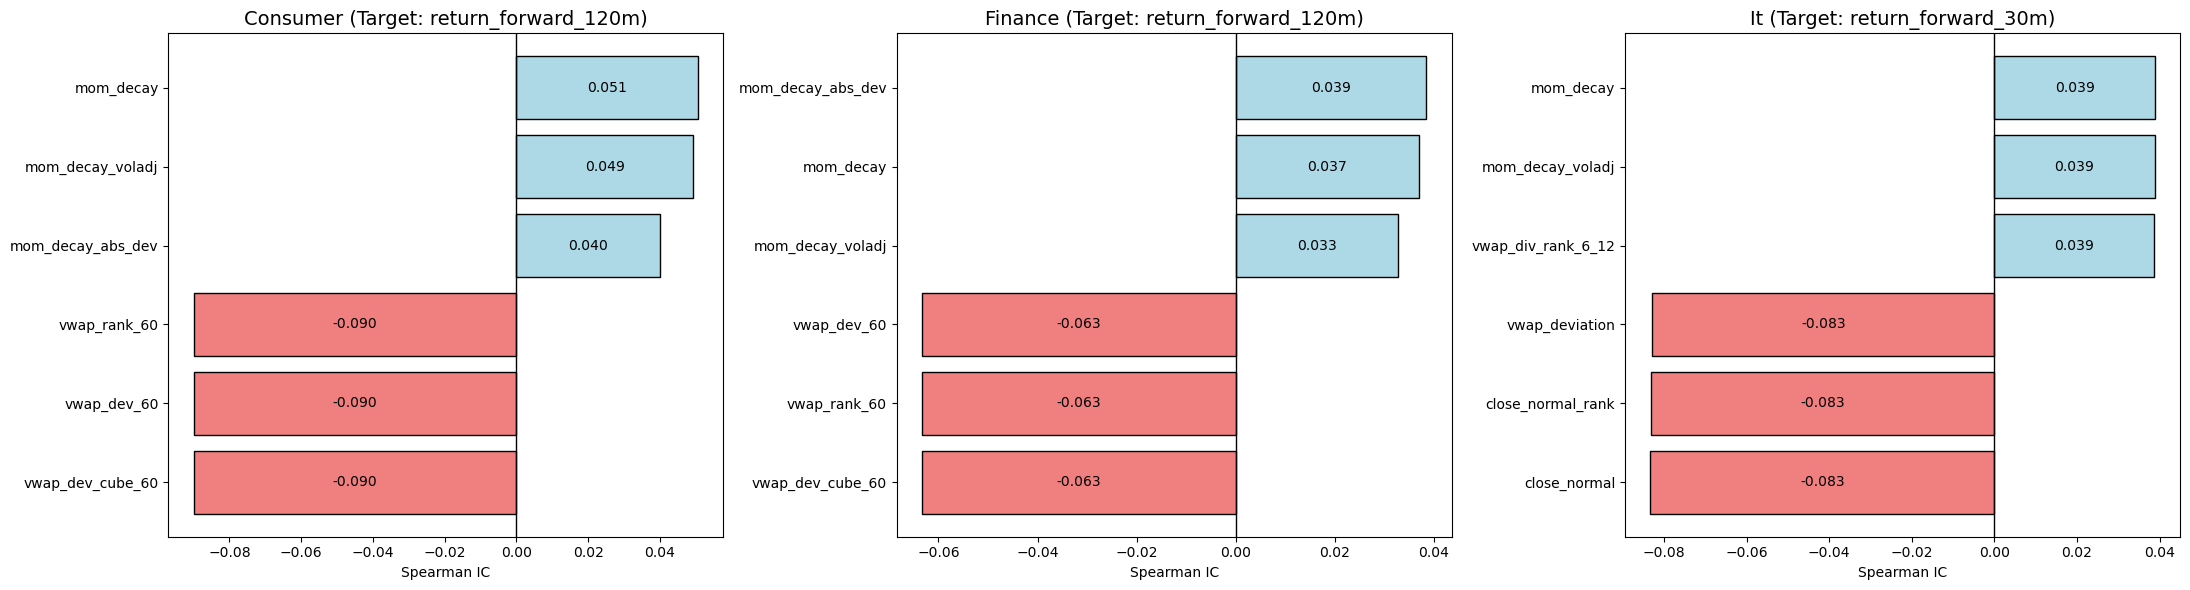

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- CONFIG ----
sector_targets = {
    "consumer": "return_forward_120m",
    "finance": "return_forward_120m",
    "it": "return_forward_30m"
}

colors = {
    "positive": "lightblue",
    "negative": "lightcoral"
}

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
axes = axes.flatten()

for ax, (sector, target) in zip(axes, sector_targets.items()):
    print(f"Plotting sector={sector}, target={target}")

    ic_df = spearman_ic_all[sector]

    # Filter only the chosen target
    target_series = ic_df[target].dropna()

    # Top 3 positive & top 3 negative
    top_pos = target_series.sort_values(ascending=False).head(3)
    top_neg = target_series.sort_values(ascending=True).head(3)

    # Build combined dataframe WITHOUT append()
    plot_df = pd.concat([
        top_pos.to_frame("IC").assign(type="positive"),
        top_neg.to_frame("IC").assign(type="negative")
    ], axis=0).sort_values("IC", ascending=False)

    # Plot
    bars = ax.barh(
        plot_df.index,
        plot_df["IC"],
        color=[colors[t] for t in plot_df["type"]],
        edgecolor="black"
    )

    # Annotate inside bars
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width / 2,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.3f}",
            ha="center", va="center", fontsize=10, color="black"
        )

    # Titles & Axes
    ax.set_title(f"{sector.title()} (Target: {target})", fontsize=14)
    ax.set_xlabel("Spearman IC")
    ax.axvline(0, color="black", linewidth=1)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()